Tensorflow

In [5]:
# Import package penting
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
import requests
import json

# URL file
url = "https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/06.%20Week%206/Datasets/DeteksiSarkasme.json"

# Ambil file dari GitHub
response = requests.get(url)
lines = response.text.strip().split("\n")  # Pisah per baris

# Parsing JSON tiap baris
data = [json.loads(line) for line in lines]

# Ekstrak data
sentences = [item['headline'] for item in data]
labels = [item['is_sarcastic'] for item in data]

print("Jumlah data:", len(sentences))
print("Contoh kalimat:", sentences[0])
print("Contoh label:", labels[0])


Jumlah data: 26709
Contoh kalimat: former versace store clerk sues over secret 'black code' for minority shoppers
Contoh label: 0


In [9]:
# Ubah tiap baris menjadi JSON object
data = [json.loads(line) for line in response.text.splitlines()]

# Ambil data headline dan label
sentences = [item['headline'] for item in data]
labels = [item['is_sarcastic'] for item in data]

In [10]:
# --- Preprocessing ---
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)
padded = pad_sequences(sequences, padding='post', truncating='post')

X = np.array(padded)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:

# --- Hyperparameter Tuning Function ---
def model_builder(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index)+1,
                                        output_dim=hp.Int('embedding_output_dim', min_value=16, max_value=64, step=16)))
    model.add(tf.keras.layers.LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)))
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [14]:
# --- Tuner ---
tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=10,
                     factor=3,
                     directory='tuner_dir',
                     project_name='sarcasm_rnn')

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[stop_early])

# --- Best Model ---
best_hps = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Trial 22 Complete [00h 00m 20s]
val_accuracy: 0.8488535284996033

Best val_accuracy So Far: 0.8528310656547546
Total elapsed time: 00h 05m 30s


In [17]:
best_hps = tuner.get_best_hyperparameters(1)[0]
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))


Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6041 - loss: 0.6546 - val_accuracy: 0.7551 - val_loss: 0.5243
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.7774 - loss: 0.5019 - val_accuracy: 0.7872 - val_loss: 0.5017
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8412 - loss: 0.4146 - val_accuracy: 0.6567 - val_loss: 0.5716
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6769 - loss: 0.5439 - val_accuracy: 0.6614 - val_loss: 0.5678
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6893 - loss: 0.5334 - val_accuracy: 0.6636 - val_loss: 0.5695
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6959 - loss: 0.5278 - val_accuracy: 0.6690 - val_loss: 0.5635
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7009 - loss: 0.5218 - val_accuracy: 0.6767 - val_loss: 0.5579
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.7083 - loss: 0.5143 - val_accuracy

In [18]:
# --- Evaluation ---
y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)

print(f"Akurasi: {acc*100:.2f}%")
print(f"Presisi: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC: {auc:.2f}")


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Akurasi: 71.06%
Presisi: 0.61
Recall: 0.95
F1 Score: 0.74
AUC: 0.86


In [19]:
train_acc = history.history['accuracy'][-1] * 100
val_acc = history.history['val_accuracy'][-1] * 100

print(f"Akurasi Training: {train_acc:.2f}%")
print(f"Akurasi Testing : {val_acc:.2f}%")


Akurasi Training: 74.08%
Akurasi Testing : 71.06%


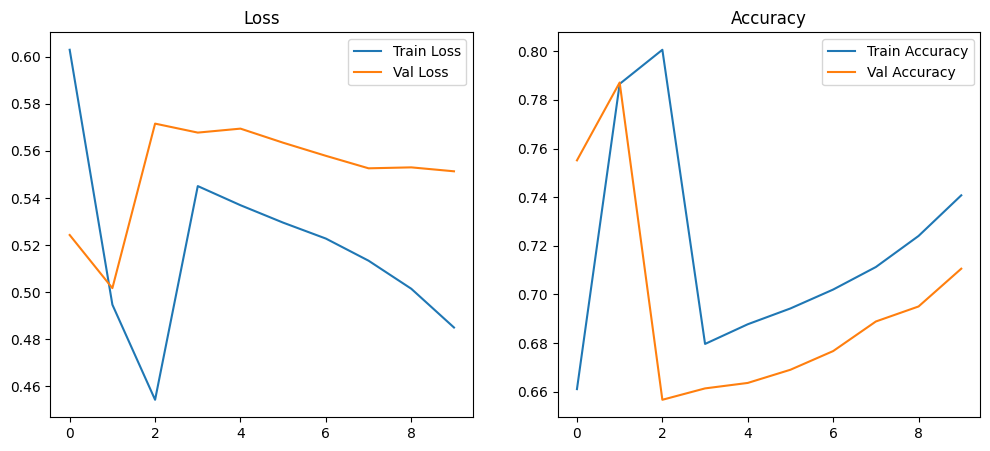

In [20]:
# --- Plot Loss & Accuracy ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

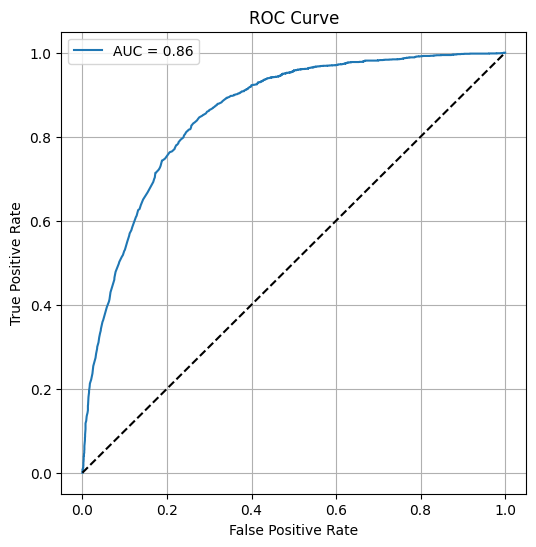

In [21]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

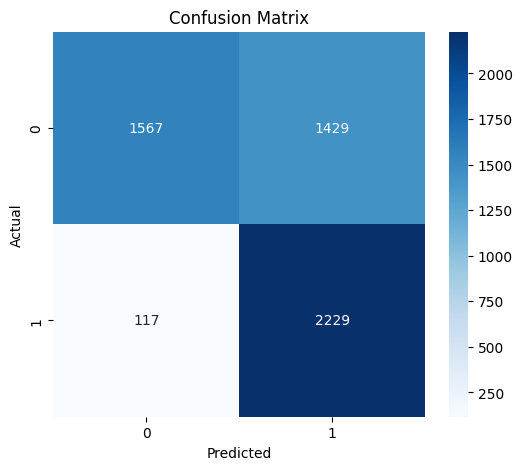

In [22]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()